# Studentprognose — Implementatietemplate

Dit notebook is een startpunt voor instellingen die `studentprognose` willen inpassen in hun eigen data-infrastructuur (Databricks, MS Fabric, lokaal script).

**Aanpakken voor jouw omgeving:**
- Stap 1: kies de juiste installatiemethode
- Stap 2: vervang de GitHub-dataloading door je eigen databron
- Stap 3: pas `YEAR`, `WEEK` en `numerus_fixus` aan
- Stap 5: schrijf output terug naar je eigen infra

## Stap 1 — Installatie

Voer deze cel eenmalig uit. In MS Fabric / Databricks herstart `%pip install` de kernel — zorg dat dit de eerste cel is die je uitvoert.

In [1]:
# MS Fabric / Databricks:
# %pip install studentprognose

# Lokaal:
# !uv pip install studentprognose

In [2]:
import io
import json
import urllib.request
from importlib.metadata import version
from pathlib import Path

import pandas as pd
from studentprognose import run_pipeline_from_dataframes, DataOption

# Workaround: save_output=False onderdrukt nog niet alle schrijfoperaties in het pakket
Path("data/output").mkdir(parents=True, exist_ok=True)

print(f"studentprognose {version('studentprognose')}")

studentprognose 1.3.1.dev10+g0c7a10d35


## Stap 2 — Data laden

Onderstaande cellen laden de **demodata** rechtstreeks van GitHub. Vervang de `pd.read_csv` / `pd.read_excel`-aanroepen door je eigen databron:

```python
# Azure Blob Storage
blob_data = blob_client.download_blob().readall()
df_cum = pd.read_csv(io.BytesIO(blob_data), sep=";", skiprows=[1])

# Databricks Delta table
df_cum = spark.table("mijn_catalog.schema.vooraanmeldingen_cumulatief").toPandas()

# MS Fabric OneLake
df_cum = pd.read_csv("/lakehouse/default/Files/vooraanmeldingen_cumulatief.csv", sep=";", skiprows=[1])
```

Het verwachte schema staat in [Je data voorbereiden](https://cedanl.github.io/studentprognose/je-data-voorbereiden/).

> `skiprows=[1]` slaat de eenheden-rij over die Studielink toevoegt aan het exportbestand. Bij data uit een eigen Delta table of database is dit niet nodig.

In [3]:
REPO_RAW = "https://raw.githubusercontent.com/cedanl/studentprognose/main"

# Cumulatieve vooraanmelddata (Studielink-formaat)
df_cum = pd.read_csv(
    f"{REPO_RAW}/data/input/vooraanmeldingen_cumulatief.csv",
    sep=";",
    skiprows=[1],
)

# Historische realisatie (optioneel — alleen nodig voor foutmaten in output)
with urllib.request.urlopen(f"{REPO_RAW}/data/input/student_count_first-years.xlsx") as resp:
    df_sc = pd.read_excel(io.BytesIO(resp.read()))

print(f"Cumulatief: {df_cum.shape[0]:,} rijen, {df_cum.shape[1]} kolommen")
print(f"Realisatie: {df_sc.shape[0]:,} rijen, {df_sc.shape[1]} kolommen")
df_cum.head(3)

Cumulatief: 25,271 rijen, 16 kolommen
Realisatie: 432 rijen, 5 kolommen


,Korte naam instelling,Collegejaar,Weeknummer rapportage,Weeknummer,Faculteit,Type hoger onderwijs,Groepeernaam Croho,Naam Croho opleiding Nederlands,Croho,Herinschrijving,Hogerejaars,Herkomst,Gewogen vooraanmelders,Ongewogen vooraanmelders,Aantal aanmelders met 1 aanmelding,Inschrijvingen
0,21PB,2016,1,1,SOW,Bachelor,B Psychologie,B Psychologie,56604,Nee,Nee,EER,2.33,3,NaN,NaN
1,21PB,2016,1,1,SOW,Bachelor,B Psychologie,B Psychologie,56604,Nee,Nee,Niet-EER,1.55,2,NaN,NaN
2,21PB,2016,1,1,MED,Bachelor,B Geneeskunde,B Geneeskunde,56551,Nee,Nee,NL,22.48,29,NaN,NaN


## Stap 3 — Configuratie en pipeline

Pas de drie variabelen hieronder aan voor jouw situatie. De configuratie wordt rechtstreeks van GitHub geladen als startpunt — vervang de `urllib`-aanroep door je eigen config-bron of pas het dict daarna aan.

Zie [Configuratie](https://cedanl.github.io/studentprognose/configuratie/) voor alle beschikbare opties.

In [4]:
YEAR = 2023  # collegejaar om te voorspellen
WEEK = 12    # peilweek (1–37)

# Configuratie ophalen van GitHub als startpunt (zelfde als de demodata)
# Vervang door je eigen config-dict of laad vanuit je eigen opslag
REPO_RAW = "https://raw.githubusercontent.com/cedanl/studentprognose/main"
with urllib.request.urlopen(f"{REPO_RAW}/configuration/configuration.json") as resp:
    config = json.load(resp)

# Numerus fixus: dict van opleiding → capaciteitslimiet
# Voeg hier de NF-opleidingen van jouw instelling toe
# config["numerus_fixus"] = {"B Geneeskunde": 340, "B Tandheelkunde": 60}

result = run_pipeline_from_dataframes(
    year=YEAR,
    week=WEEK,
    data_cumulative=df_cum,
    data_student_numbers=df_sc,
    configuration=config,
    dataset=DataOption.CUMULATIVE,
    save_output=False,
)

print(f"Resultaat: {result.shape[0]} rijen, {result.shape[1]} kolommen")

Preprocessing...



  Dataset:       cumulatief
  Trainingsdata: jaren 2016-2024
  Voorspelling:  jaar [2023], vanaf week [12]
  Voorspelt:     week 13 t/m 38 (26 weken vooruit)
  Opleidingen:   B Bedrijfskunde, B Biomedische Wetenschappen, B Communicatiewetenschap, B Filosofie, B Geneeskunde, B Geschiedenis, B Kunstmatige Intelligentie, B Natuurkunde, B Politicologie, B Psychologie, B Scheikunde, B Wiskunde, M Bestuurskunde, M Cognitive Neuroscience, M Informatica, M Linguistiek, M Molecular Mechanisms of Disease, M Rechtsgeleerdheid

Predicting first-years: 2023-12...
Start parallel predicting...


Postprocessing...
Resultaat: 1458 rijen, 23 kolommen


## Stap 4 — Resultaten bekijken

In [5]:
print("Beschikbare kolommen:", result.columns.tolist())

# Bepaal de primaire voorspelkolom op basis van wat beschikbaar is
_pred_candidates = [
    "Weighted_ensemble_prediction", "SARIMA_cumulative",
    "SARIMA_individual", "Prognose_ratio",
]
pred_col = next((c for c in _pred_candidates if c in result.columns), result.columns[-1])

cols = [c for c in [
    "Croho groepeernaam", "Herkomst", "Examentype",
    pred_col, "Prognose_ratio", "Aantal_studenten",
] if c in result.columns]

result[cols].sort_values(pred_col, ascending=False).head(10)

Beschikbare kolommen: ['Croho groepeernaam', 'Faculteit', 'Examentype', 'Collegejaar', 'Herkomst', 'Weeknummer', 'SARIMA_cumulative', 'SARIMA_individual', 'Voorspelde vooraanmelders', 'Aantal_studenten', 'Gewogen vooraanmelders', 'Ongewogen vooraanmelders', 'Aantal aanmelders met 1 aanmelding', 'Inschrijvingen', 'Aanmelding', 'Ratio', 'Average_Ratio', 'Prognose_ratio', 'Baseline', 'MAE_Prognose_ratio', 'MAE_SARIMA_cumulative', 'MAPE_Prognose_ratio', 'MAPE_SARIMA_cumulative']


,Croho groepeernaam,Herkomst,Examentype,SARIMA_cumulative,Prognose_ratio,Aantal_studenten
28,B Psychologie,NL,Bachelor,485.0,496.505639,478
13,B Geneeskunde,NL,Bachelor,381.0,428.491484,454
19,B Kunstmatige Intelligentie,NL,Bachelor,289.0,315.991662,345
1,B Bedrijfskunde,NL,Bachelor,265.0,299.346780,307
4,B Biomedische Wetenschappen,NL,Bachelor,206.0,186.443486,232
7,B Communicatiewetenschap,NL,Bachelor,200.0,218.871696,187
25,B Politicologie,NL,Bachelor,162.0,184.818587,151
16,B Geschiedenis,NL,Bachelor,130.0,119.935671,127
52,M Rechtsgeleerdheid,NL,Master,123.0,133.948312,113
34,B Wiskunde,NL,Bachelor,106.0,110.883614,94


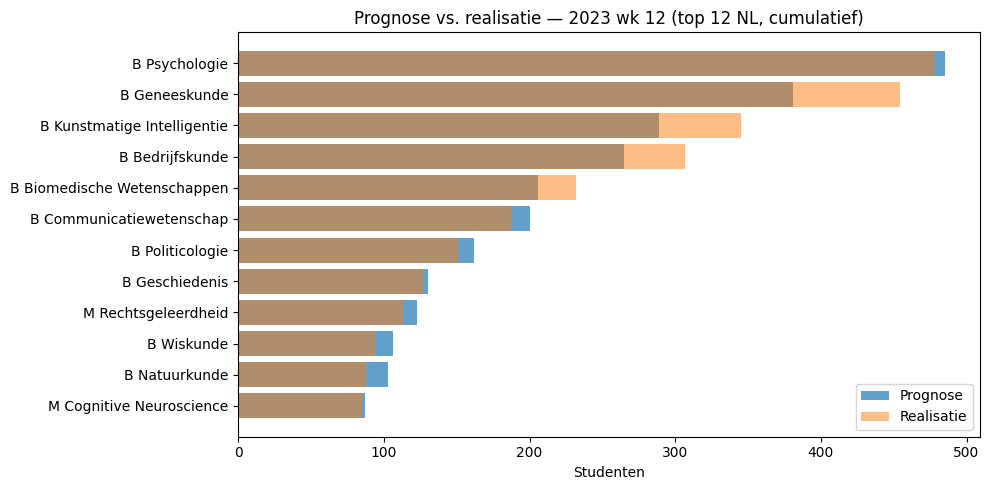

In [6]:
import matplotlib.pyplot as plt

real_col = "Aantal_studenten"

if real_col in result.columns:
    plot_df = result.copy()
    if "Herkomst" in plot_df.columns:
        plot_df = plot_df[plot_df["Herkomst"] == "NL"]
    plot_df = (
        plot_df[["Croho groepeernaam", pred_col, real_col]]
        .dropna()
        .sort_values(pred_col, ascending=True)
        .tail(12)
    )

    x = list(range(len(plot_df)))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(x, plot_df[pred_col], label="Prognose", alpha=0.7)
    ax.barh(x, plot_df[real_col], label="Realisatie", alpha=0.5)
    ax.set_yticks(x)
    ax.set_yticklabels(plot_df["Croho groepeernaam"].str[:30])
    ax.set_xlabel("Studenten")
    ax.set_title(f"Prognose vs. realisatie — {YEAR} wk {WEEK} (top 12 NL, cumulatief)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Geen realisatiedata beschikbaar voor vergelijking.")

## Stap 5 — Output terugschrijven (optioneel)

Schrijf het resultaat terug naar je eigen infra:

```python
# Lokaal
result.to_excel(f"prognose_{YEAR}_wk{WEEK}.xlsx", index=False)

# Azure Blob Storage
blob_client.upload_blob(result.to_csv(index=False), overwrite=True)

# Databricks Delta table
spark.createDataFrame(result).write.mode("overwrite").saveAsTable("mijn_catalog.schema.prognose")
```

Zie [Output begrijpen](https://cedanl.github.io/studentprognose/output-begrijpen/) voor een toelichting op alle outputkolommen.

---

Wil je dieper in de methodologie duiken? Zie de [documentatie](https://cedanl.github.io/studentprognose/methodologie/).